In [1]:
import numpy as np


class LeastSquaresMethodLine:
    """
    Класс для аппроксимации некоторой таблично заданной функции прямой
    """

    def __init__(self,
                 x: np.ndarray,
                 y: np.ndarray
                 ) -> None:
        """
        Инициализация атрибутов класса
        """
        self.__x = x
        self.__y = y
        self.__n = len(self.__x)

        self.__sum_x = sum(self.__x)
        self.__sum_y = sum(self.__y)
        self.__sum_x_squ = self.__get_sum_x_squ()
        self.__sum_xy = self.__get_sum_xy()

    def __get_sum_x_squ(self):
        """
        Метод для подсчета суммы квадратов значений аргумента
        """
        sum_x_squ = 0

        for x in self.__x:
            sum_x_squ += (x * x)

        return sum_x_squ

    def __get_sum_xy(self):
        """
        Метод для подсчета суммы произведений xy
        """
        sum_xy = 0

        for i in range(self.__n):
            sum_xy += (self.__x[i] * self.__y[i])

        return sum_xy

    def get_solve(self):
        """
        Метод для получения коэффициентов уравнения прямой
        уравнение прямой: y = a * x + b
        """
        b = (self.__sum_xy * self.__sum_x - self.__sum_y * self.__sum_x_squ) / (
                self.__sum_x ** 2 - self.__sum_x_squ * self.__n)

        a = (self.__sum_y - b * self.__n) / self.__sum_x

        return a, b

u[n_eq] = u[100] = 3.0612272e-07, len(u) = 101


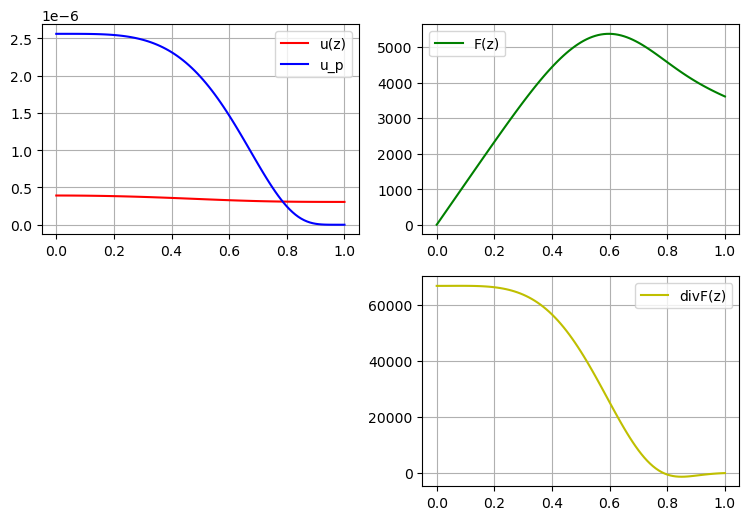

In [3]:
import numpy as np
from matplotlib import pyplot as plt

"""
https://swsu.ru/sveden/files/MU_Vychislitelynaya_matematika_LZNo_4.pdf
про аппроксимацию производной конечными разностями
"""

"""
https://elib.utmn.ru/jspui/bitstream/ru-tsu/3444/1/Gavrilova_1011_2019.pdf
откуда взял инфу о встречной прогонке
"""

"""
https://ru.wikipedia.org/wiki/Формула_Симпсона
откуда взял инфу про составную формулу Симпсона (формула Котеса)
"""

# отладочные параметры
r = 0.35
t_w = 2000
t_0 = 1e4
p = 4

c = 3e10

# таблица значений k
t_k = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
k_1 = [8.2E-3, 2.768E-02, 6.560E-02, 1.281E-01, 2.214E-01, 3.516E-01, 5.248E-01, 7.472E-01, 1.025E+00]
k_2 = [1.600E+00, 5.400E+00, 1.280E+01, 2.500E+01, 4.320E+01, 6.860E+01, 1.024E+02, 1.458E+02, 2.000E+02]

# коэффициенты уравнений прямых при аппроксимации таблицы значений с
# коэффициентом поглощения
a1, b1 = LeastSquaresMethodLine(x=np.log(t_k), y=np.log(k_1)).get_solve()
a2, b2 = LeastSquaresMethodLine(x=np.log(t_k), y=np.log(k_2)).get_solve()

is_k1 = True
# is_k1 = False

EPS = 1e-4


def t(z: int | float | np.ndarray):
    """
    T(z)- температурное поле в цилиндре.
    """

    return (t_w - t_0) * z ** p + t_0


def u_p(z: int | float | np.ndarray):
    """
    Функция Планка
    """

    return 3.084e-4 / (np.exp(4.799e4 / t(z)) - 1)


def k1(_t: int | float | np.ndarray):
    """
    Функция для получения значения первого варианта коэффициента поглощения
    в точках между узлами
    """

    return np.exp(a1 * np.log(t(_t)) + b1)


def k2(_t: int | float | np.ndarray):
    """
    Функция для получения значения второго варианта коэффициента поглощения
    в точках между узлами
    """

    return np.exp(a2 * np.log(t(_t)) + b2)


def der_u(z, _f):
    """
    Функция правой части первого уравнения
    f = f(z) - значение функции F в точке z
    """
    # мда, треш, долго доходило, что не k(z), а k(t(z))
    if is_k1:
        return -3 * r * k1(t(z)) / c * _f

    return -3 * r * k2(t(z)) / c * _f


def der_f(z, u, _f):
    """
    Функция правой части первого уравнения
    f = f(z) - значение функции F в точке z
    u = u(z) - значение функции u в точке z
    """
    if is_k1:
        common_part = r * c * k1(t(z)) * (u_p(z) - u)
    else:
        common_part = r * c * k2(t(z)) * (u_p(z) - u)

    res = -_f / z + common_part if abs(z) > EPS else common_part / 2

    return res


def div_flux(z, u):
    """
    divF(z)
    """
    if is_k1:
        return c * k1(z) * (u_p(z) - u)

    return c * k2(z) * (u_p(z) - u)


def _lambda(z):
    """
    Функция λ(z)
    """
    if is_k1:
        return c / (3 * k1(z))

    return c / (3 * k2(z))


def _lambda_new(z):
    """
    Функция λ(z) без с
    """
    if is_k1:
        return 1 / (3 * k1(z))

    return 1 / (3 * k2(z))


def _p(z):
    """
    Функция p(z)
    """
    if is_k1:
        return c * k1(z)

    return c * k2(z)


def f(z):
    """
    Функция f(z)
    """
    if is_k1:
        return c * k1(z) * u_p(z)

    return c * k2(z) * u_p(z)


def _p_new(z):
    """
    Функция p(z) без с
    """
    if is_k1:
        return 1 * k1(z)

    return 1 * k2(z)


def f_new(z):
    """
    Функция f(z) без с
    """
    if is_k1:
        return 1 * k1(z) * u_p(z)

    return 1 * k2(z) * u_p(z)


def v_n(z, h):
    """
    Элемент объема
    """

    return ((z + h / 2) ** 2 - (z - h / 2) ** 2) / 2


def kappa1(z1, z2):
    """
    Функция каппа (вычисляется с использованием метода средних)
    """

    return (_lambda(z1) + _lambda(z2)) / 2


def kappa2(z1, z2):
    """
    Функция каппа (вычисляется с использованием метода трапеций)
    """

    return (2 * _lambda(z1) * _lambda(z2)) / (_lambda(z1) + _lambda(z2))


def kappa_new(z1, z2):
    """
    Убрали скорость света
    """

    return (_lambda_new(z1) + _lambda_new(z2)) / 2


def left_boundary_condition(z0, g0, h):
    """
    Левое краевое условие метода правой прогонки
    """

    p_half = (_p_new(z0) + _p_new(z0 + h)) / 2
    f_half = (f_new(z0) + f_new(z0 + h)) / 2

    k0 = kappa_new(z0, z0 + h) * (z0 + h / 2) / (r ** 2 * h) - p_half * (z0 + h / 2) * h / 8  # правильно

    m0 = -kappa_new(z0, z0 + h) * (z0 + h / 2) / (r ** 2 * h) - p_half * (z0 + h / 2) * h / 8 - _p_new(
        z0) * z0 * h / 4

    p0 = -z0 * g0 / r - (f_half * (z0 + h / 2) + f_new(z0) * z0) * h / 4

    return k0, m0, p0


# При x = N
def right_boundary_condition(zn, h):
    """
    Правое краевое условие метода правой прогонки
    """
    p_half = (_p_new(zn) + _p_new(zn - h)) / 2
    f_half = (f_new(zn) + f_new(zn - h)) / 2

    kn = kappa_new(zn - h, zn) * (zn - h / 2) / (r ** 2 * h) - p_half * (zn - h / 2) * h / 8  # правильно

    mn = -kappa_new(zn - h, zn) * (zn - h / 2) / (r ** 2 * h) - 0.393 * 1 * zn / r - _p_new(
        zn) * zn * h / 4 - p_half * (zn - h / 2) * h / 8

    pn = -(f_new(zn) * zn + f_half * (zn - h / 2)) * h / 4

    return kn, mn, pn


def right_sweep(a, b, h):
    """
    Реализация правой прогонки
    """
    # Прямой ход
    k0, m0, p0 = left_boundary_condition(a, 0, h)
    kn, mn, pn = right_boundary_condition(b, h)

    ksi = [0, -k0 / m0]
    eta = [0, p0 / m0]

    z = h
    n = 1

    while z < b + h / 2:
        a_n = (z - h / 2) * (kappa_new(z - h, z)) / (r ** 2 * h)
        c_n = ((z + h / 2) * kappa_new(z, z + h)) / (r ** 2 * h)
        b_n = a_n + c_n + _p_new(z) * v_n(z, h)
        d_n = f_new(z) * v_n(z, h)

        ksi.append(c_n / (b_n - a_n * ksi[n]))
        eta.append((a_n * eta[n] + d_n) / (b_n - a_n * ksi[n]))

        n += 1
        z += h

    # Обратный ход
    u = [0] * n

    u[n - 1] = (pn - kn * eta[n - 1]) / (kn * ksi[n - 1] + mn)

    # print(f"u[n - 1] = u[{n - 1}] = {u[n - 1]: <.7e}, len(u) = {len(u)}")

    for i in range(n - 2, -1, -1):
        u[i] = ksi[i + 1] * u[i + 1] + eta[i + 1]

    return u


def left_sweep(a, b, h):
    """
    Реализация левой прогонки
    """

    # Прямой ход
    k0, m0, p0 = left_boundary_condition(a, 0, h)
    kn, mn, pn = right_boundary_condition(b, h)

    ksi = [-kn / mn, 0]
    eta = [pn / mn, 0]

    z = b - h
    n = -2
    cnt = 1

    while z > a - h / 2:
        a_n = (z - h / 2) * (kappa_new(z - h, z)) / (r ** 2 * h)
        c_n = ((z + h / 2) * kappa_new(z, z + h)) / (r ** 2 * h)
        b_n = a_n + c_n + _p_new(z) * v_n(z, h)
        d_n = f_new(z) * v_n(z, h)

        ksi.insert(0, a_n / (b_n - c_n * ksi[n]))
        eta.insert(0, (c_n * eta[n] + d_n) / (b_n - c_n * ksi[n]))

        n -= 1
        z -= h
        cnt += 1

    # Обратный ход
    u = [0] * cnt

    u[0] = (p0 - k0 * eta[0]) / (m0 + k0 * ksi[0])

    for i in range(1, cnt):
        u[i] = ksi[i - 1] * u[i - 1] + eta[i - 1]

    return u


def meetings_sweep(a, b, h, n_eq):
    """
    Реализация встречной прогонки
    """
    # Прямой ход
    k0, m0, p0 = left_boundary_condition(a, 0, h)
    kn, mn, pn = right_boundary_condition(b, h)

    # правая часть прогонки
    z = h
    n = 1

    ksi_r = [0, -k0 / m0]
    eta_r = [0, p0 / m0]

    while z < n_eq * h - h / 2:
        a_n = (z - h / 2) * (kappa_new(z - h, z)) / (r ** 2 * h)
        c_n = ((z + h / 2) * kappa_new(z, z + h)) / (r ** 2 * h)
        b_n = a_n + c_n + _p_new(z) * v_n(z, h)
        d_n = f_new(z) * v_n(z, h)

        ksi_r.append(c_n / (b_n - a_n * ksi_r[n]))
        eta_r.append((a_n * eta_r[n] + d_n) / (b_n - a_n * ksi_r[n]))

        n += 1
        z += h

    # левая часть прогонки
    ksi_l = [-kn / mn, 0]
    eta_l = [pn / mn, 0]

    z = b - h
    n1 = -2
    cnt = 1

    while z > n_eq * h:
        print(f"[+] in while")
        a_n = (z - h / 2) * (kappa_new(z - h, z)) / (r ** 2 * h)
        c_n = ((z + h / 2) * kappa_new(z, z + h)) / (r ** 2 * h)
        b_n = a_n + c_n + _p_new(z) * v_n(z, h)
        d_n = f_new(z) * v_n(z, h)

        ksi_l.insert(0, a_n / (b_n - c_n * ksi_l[n1]))
        eta_l.insert(0, (c_n * eta_l[n1] + d_n) / (b_n - c_n * ksi_l[n1]))

        n1 -= 1
        z -= h
        cnt += 1

    # # Обратный ход
    u = [0] * (n + cnt)

    # вычисляем up (решая систему из двух уравнений) -- сопряжение решений
    u[n_eq] = (ksi_r[-1] * eta_l[0] + eta_r[-1]) / (1 - ksi_r[-1] * ksi_l[0])

    print(f"u[n_eq] = u[{n_eq}] = {u[n_eq]: <.7e}, len(u) = {len(u)}")
    # print(f"U в точке p = {n_eq} равно {u[n_eq]: <.7e}")

    for i in range(n_eq - 1, -1, -1):
        u[i] = ksi_r[i + 1] * u[i + 1] + eta_r[i + 1]

    for i in range(n_eq + 1, n + cnt):
        print(f"[+] in for")
        _i = i - n_eq
        u[i] = ksi_l[_i - 1] * u[i - 1] + eta_l[_i - 1]

    return u


def flux1(u, z, h):
    """
    Вычисление F(z) аппроксимацией производной центральным аналогом
    (2-й порядок точности)
    """
    f_res = [0]

    for i in range(1, len(u) - 1):
        curr_f = -(_lambda(z[i]) / r) * (u[i + 1] - u[i - 1]) / (2 * h)
        f_res.append(curr_f)

    f_res.append(-(_lambda(z[len(u) - 1]) / r) * (3 * u[-1] - 4 * u[-2] + u[-3]) / (2 * h))

    return f_res


def flux2(z, u, h):
    """
    Метод трапеций для вычисления интеграла при получении F(z)
    """
    _f = [0]
    f_res = [0]

    if is_k1:
        k = k1
    else:
        k = k2

    for i in range(1, len(z)):
        _f.append(k(z[i]) * (u_p(z[i]) - u[i]) * z[i])
        f_res.append((c * r / z[i]) * h * ((_f[0] + _f[i]) / 2 + sum(_f[1:-1])))

    return f_res


def flux3(z, u, h):
    """
    Метод Симпсона для вычисления интеграла при получении F(z)
    """
    _f = [0]
    f_res = [0]

    if is_k1:
        k = k1
    else:
        k = k2

    for i in range(1, len(z)):
        _f.append(k(z[i]) * (u_p(z[i]) - u[i]) * z[i])

        _sum = 0

        for _k in range(1, len(z[:i]), 2):
            _sum += (_f[_k - 1] + 4 * _f[_k] + _f[_k + 1])

        f_res.append((c * r / z[i]) * (h / 3) * _sum)

    return f_res


def get_research():
    """
    Исследование правой прогонки по полной
    """
    table_size = 85
    a, b = 0, 1

    n_list = [100, 70, 50, 30, 20, 10]

    file = open("../data/research.txt", "w", encoding="utf-8")

    file.write("-" * table_size + "\n")
    file.write(f' {"n": ^7} | {"u(0)": ^22} | {"u(1)": ^22} | {"f(1)": ^22} |\n')
    file.write("-" * table_size + "\n")

    for n in n_list:
        h = (b - a) / n

        u_res = right_sweep(a, b, h)
        # u_res = left_sweep(a, b, h)
        z_res = np.arange(a, b + h / 2, h)
        f_res = flux3(z_res, u_res, h)

        file.write(f"{n: 8} | {u_res[0]: ^22.6e} | {u_res[-1]: ^22.6e} | {f_res[-1]: ^22.6e} |\n")

    file.write("-" * table_size)

    file.close()


def write_result_to_file(filepath, z_res, u_res, f_res, f_res2):
    """
    Запись результатов в файл
    """
    file = open(filepath, "w", encoding="utf-8")

    file.write(f"Число узлов n = {len(z_res)}\n")
    file.write("-" * 86 + "\n")
    file.write(f'| {"x": ^7} | {"u(z)": ^22} | {"f(z)": ^22} | {"f(z) integral": ^22} |\n')
    file.write("-" * 86 + "\n")

    # for i in range(len(z_res)):
    #     file.write(f"| {z_res[i]: ^7.5f} | {u_res[i]: ^22.6e} | {f_res[i]: ^22.6e} | {f_res2[i]: ^22.6e} |\n")

    for i in [0, len(u_res) - 1]:
        file.write(f"| {z_res[i]: ^7.5f} | {u_res[i]: ^22.6e} | {f_res[i]: ^22.6e} | {f_res2[i]: ^22.6e} |\n")

    file.write("-" * 86)

    file.close()


def main() -> None:
    """
    Главная функция
    """
    # get_research()
    a, b = 0, 1
    n = 100  # число узлов
    h = (b - a) / n

    u_res = right_sweep(a, b, h)
    u_res = left_sweep(a, b, h)
    u_res = meetings_sweep(a, b, h, n)
    z_res = np.arange(a, b + h / 2, h)
    
    # f_res = flux1(u_res, z_res, h)
    f_res = flux2(z_res, u_res, h)
    # f_res2 = flux3(z_res, u_res, h)
    # f_res2 = [0] * len(z_res)
    # for i in range(1, len(z_res)):
    #     f_res2[i] = flux2(z_res[i], h, u_res[i - 1], u_res[i])
    
    up_res = [0] * len(z_res)
    div_f = [0] * len(z_res)
    
    for i in range(len(z_res)):
        up_res[i] = u_p(z_res[i])
        div_f[i] = div_flux(z_res[i], u_res[i])

    # write_result_to_file("../data/right_sweep.txt", z_res, u_res, f_res, f_res2)
    # write_result_to_file("../data/left_sweep.txt", z_res, u_res, f_res, f_res2)
    # write_result_to_file("../data/meetings_sweep.txt", z_res, u_res, f_res, f_res2)

    plt.figure(figsize=(9, 6))
    plt.subplot(2, 2, 1)
    plt.plot(z_res, u_res, 'r', label='u(z)')
    plt.plot(z_res, up_res, 'b', label='u_p')
    plt.legend()
    plt.grid()
    
    plt.subplot(2, 2, 2)
    plt.plot(z_res, f_res, 'g', label='F(z)')
    plt.legend()
    plt.grid()
    
    # plt.subplot(2, 2, 3)
    # plt.plot(z_res, f_res2, 'g', label='F(z) integral')
    # plt.legend()
    # plt.grid()
    
    plt.subplot(2, 2, 4)
    plt.plot(z_res, div_f, 'y', label='divF(z)')
    plt.legend()
    plt.grid()
    
    plt.show()

    # cmp_res_by_input_data(a, b, h)


if __name__ == '__main__':
    main()

In [4]:
from decimal import Decimal, getcontext

getcontext().prec = 50

# Константы
c_ = float(Decimal('3e10'))       # Скорость света
R_ = Decimal('0.35')     # Радиус цилиндра
T_w_ = Decimal('2000')     # Температура на стенке
T_0_ = Decimal('10000')    # Температура в центре
p_ = Decimal('4')        # Параметр температурного профиля

r_start_ = Decimal('0')
r_end_ = R_
F0_ = Decimal('0')
n_steps_ = 100
tol_=Decimal('1e-8')
max_iter_=1000

u[n_eq] = u[100] = 3.0612272e-07, len(u) = 101
err 1.5866593262471349230370298919062736909114143393273E-9


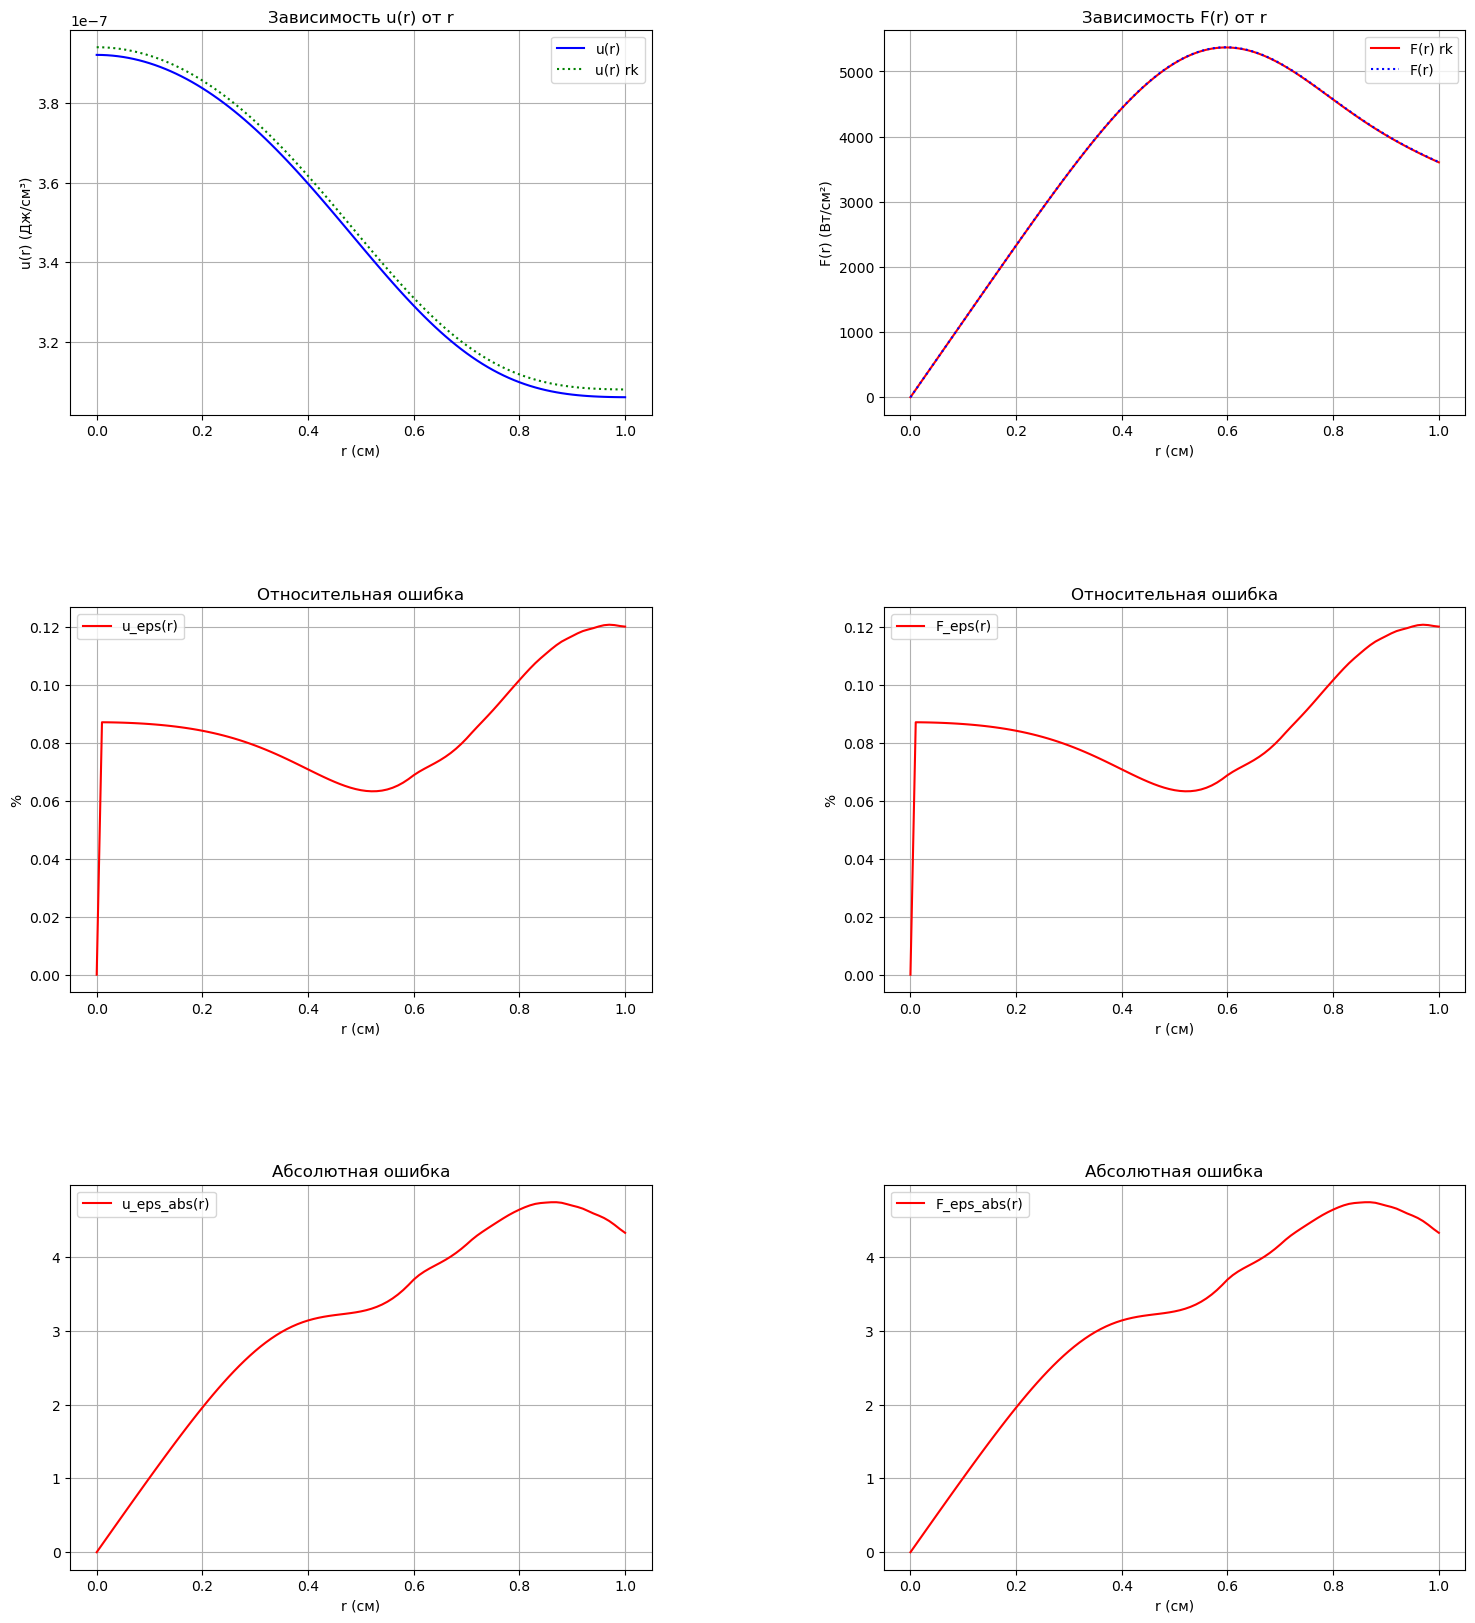

In [9]:
import lab_02_lib


a, b = 0, 1
n = 100
h = (b - a) / n

u_res = right_sweep(a, b, h)
u_res = left_sweep(a, b, h)
u_res = meetings_sweep(a, b, h, n)
z_res = np.arange(a, b + h / 2, h)
# f_res = flux1(u_res, z_res, h)
f_res = flux2(z_res, u_res, h)

chi_opt = lab_02_lib.shooting_method(r_start_, r_end_, F0_, n_steps_, lab_02_lib.rk4, tol=tol_, max_iter=max_iter_)
u0_opt = chi_opt * lab_02_lib.u_p(0)
solution = lab_02_lib.rk4(r_start_, r_end_, u0_opt, F0_, n_steps_)
r_vals = [float(x[0])/float(R_) for x in solution]
u_vals = [float(x[1]) for x in solution]
F_vals = [float(x[2]) for x in solution]

# График u(r)

eps_vals_u = [abs(f_res[i] - F_vals[i]) * 100 / (float(tol_) if F_vals[i] < float(tol_) else F_vals[i]) for i in range(len(f_res))]
eps_vals_abs_u = [abs(f_res[i] - F_vals[i]) for i in range(len(f_res))]      

eps_vals = [abs(f_res[i] - F_vals[i]) * 100 / (float(tol_) if F_vals[i] < float(tol_) else F_vals[i]) for i in range(len(f_res))] 
eps_vals_abs = [abs(f_res[i] - F_vals[i]) for i in range(len(f_res))]   
    # Настройка графиков (3 строки, 2 столбца)
plt.figure(figsize=(18, 20))  # Увеличиваем высоту для 3 строк
plt.subplots_adjust(hspace=0.5, wspace=0.4)  # Больше отступов

plt.subplot(3, 2, 1)
plt.plot(z_res, u_res, 'b-', label='u(r)')
plt.plot(r_vals, u_vals, 'g:', label='u(r) rk')
plt.xlabel('r (см)')
plt.ylabel('u(r) (Дж/см³)')
plt.title('Зависимость u(r) от r')
plt.grid(True)
plt.legend()

# График F(r)
plt.subplot(3, 2, 2)
plt.plot(r_vals, F_vals, 'r-', label='F(r) rk')
plt.plot(z_res, f_res, 'b:', label='F(r)')
plt.xlabel('r (см)')
plt.ylabel('F(r) (Вт/см²)')
plt.title('Зависимость F(r) от r')
plt.grid(True)
plt.legend()

# График ошибки u(r)
plt.subplot(3, 2, 3)
plt.plot(r_vals, eps_vals_u, 'r-', label='u_eps(r)')
plt.xlabel('r (см)')
plt.ylabel('%')
plt.title('Относительная ошибка')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 5)
plt.plot(r_vals, eps_vals_abs_u, 'r-', label='u_eps_abs(r)')
plt.xlabel('r (см)')
# plt.ylabel('F(r) (Вт/см²)')
plt.title('Абсолютная ошибка')
plt.grid(True)
plt.legend()

slice_perc = int(len(r_vals) * 0.01)

# График ошибки F(r)
plt.subplot(3, 2, 4)
plt.plot(r_vals, eps_vals, 'r-', label='F_eps(r)')
plt.xlabel('r (см)')
plt.ylabel('%')
plt.title('Относительная ошибка')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 6)
plt.plot(r_vals, eps_vals_abs, 'r-', label='F_eps_abs(r)')
plt.xlabel('r (см)')
# plt.ylabel('F(r) (Вт/см²)')
plt.title('Абсолютная ошибка')
plt.grid(True)
plt.legend()
